# FIN 4000 Supplement 2: Duration and Convexity as Derivatives
*SymPy and QuantLib companion to the study guide*

This notebook runs every calculation in the study guide [`supp-02-duration-and-convexity-as-derivatives.md`](../../study-guides/supplements/supp-02-duration-and-convexity-as-derivatives.md). Run the cells from top to bottom. Each section matches a section of the guide.

**You will:**
- differentiate a bond price function symbolically and read off $D^*$ and $C$
- compare Taylor approximations of different orders with exact repricing
- see the derivative as a limit with finite differences
- check convexity as duration squared plus variance
- confirm the numbers with QuantLib
- test Redington's immunization conditions

**Running example:** a 10-year bond with a 6% annual coupon and \$1,000 face value, priced at a 6% yield.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt
import QuantLib as ql

print("SymPy", sp.__version__, "| QuantLib", ql.__version__)

SymPy 1.14.0 | QuantLib 1.43


## 2. The price function (guide Section 1)

$$P(y) = \sum_{t} CF_t\,(1+y)^{-t}$$

`y` is a SymPy symbol, so `P` is an expression we can differentiate.

In [2]:
y = sp.symbols('y')
face, coupon, T = 1000, 60, 10
P = sum(sp.Integer(coupon) / (1 + y)**t for t in range(1, T + 1)) + sp.Integer(face) / (1 + y)**T
y0 = sp.Rational(6, 100)

print("Price at y = 6%:", float(P.subs(y, y0)))

Price at y = 6%: 1000.0


## 3. Duration is the first derivative (guide Sections 2 and 3)

$$D^{*} = -\frac{1}{P}\frac{dP}{dy} \qquad D_{mac} = D^{*}\,(1+y)$$

In [3]:
dP = sp.diff(P, y)                    # first derivative of the price function
Dstar = -dP / P                       # D* = -(1/P) dP/dy

D_star = float(Dstar.subs(y, y0))
D_mac = D_star * 1.06
print("Modified duration D* =", round(D_star, 4))
print("Macaulay duration    =", round(D_mac, 4))
print("DV01 per $1,000 face =", round(float(-dP.subs(y, y0)) * 0.0001, 4))

Modified duration D* = 7.3601
Macaulay duration    = 7.8017
DV01 per $1,000 face = 0.736


**Closed forms by symbolic differentiation.** The zero-coupon bond and the perpetuity are the two checks in the guide.

In [4]:
F, c, Tm = sp.symbols('F c T', positive=True)
yy = sp.symbols('y', positive=True)

zero = F * (1 + yy)**(-Tm)
perp = c / yy

print("zero-coupon  D* =", sp.simplify(-sp.diff(zero, yy) / zero))
print("zero-coupon  C  =", sp.simplify(sp.diff(zero, yy, 2) / zero))
print("perpetuity   D* =", sp.simplify(-sp.diff(perp, yy) / perp))
print("perpetuity   C  =", sp.simplify(sp.diff(perp, yy, 2) / perp))

zero-coupon  D* = T/(y + 1)
zero-coupon  C  = T*(T + 1)/(y + 1)**2
perpetuity   D* = 1/y
perpetuity   C  = 2/y**2


## 4. Convexity is the second derivative (guide Section 4)

$$C = \frac{1}{P}\frac{d^{2}P}{dy^{2}}$$

In [5]:
d2P = sp.diff(P, y, 2)                # second derivative
Cvx = d2P / P

C_val = float(Cvx.subs(y, y0))
print("Convexity C =", round(C_val, 4))

Convexity C = 69.7404


## 5. Taylor series and the approximation error (guide Section 5)

$$\frac{\Delta P}{P} \approx -D^{*}\,\Delta y + \tfrac{1}{2}\,C\,(\Delta y)^{2} + \tfrac{1}{6}\,\frac{P'''}{P}\,(\Delta y)^{3}$$

In [6]:
d3P = sp.diff(P, y, 3)                # third derivative
P0 = P.subs(y, y0)
third = float((d3P / P).subs(y, y0))
print("P'''/P =", round(third, 2))

rows = []
for dy in (0.02, 0.01, -0.01, -0.02):
    exact = float(P.subs(y, y0 + sp.Rational(str(dy))) / P0 - 1)
    first = -D_star * dy
    second = first + 0.5 * C_val * dy**2
    third_order = second + third / 6 * dy**3
    rows.append([f"{dy * 100:+.0f} pt", exact, first, second, third_order])

table = pd.DataFrame(rows, columns=["yield change", "exact", "duration only", "+ convexity", "+ third order"])
(table.set_index("yield change") * 100).round(4)

P'''/P = -753.69


,exact,duration only,+ convexity,+ third order
yield change,,,,
+2 pt,-13.4202,-14.7202,-13.3254,-13.4259
+1 pt,-7.0236,-7.3601,-7.0114,-7.0239
-1 pt,7.7217,7.3601,7.7088,7.7214
-2 pt,16.2218,14.7202,16.1150,16.2155


**The derivative as a limit.** A central difference with a shrinking step $h$ approaches $D^*$ and $C$.

In [7]:
def price(yv):
    t = np.arange(1, 11)
    cf = np.full(10, 60.0)
    cf[-1] += 1000
    return float((cf / (1 + yv)**t).sum())

rows = []
for h in (1e-2, 1e-3, 1e-4):
    p0, up, dn = price(0.06), price(0.06 + h), price(0.06 - h)
    rows.append([h, -(up - dn) / (2 * h) / p0, (up - 2 * p0 + dn) / h**2 / p0])

pd.DataFrame(rows, columns=["step h", "D* (central difference)", "C (second difference)"]).set_index("step h").round(4)

,D* (central difference),C (second difference)
step h,,
0.0100,7.3727,69.8153
0.0010,7.3602,69.7411
0.0001,7.3601,69.7404


## 6. Convexity is duration squared plus variance (guide Section 6)

Treat the payment time $T$ as a random variable with probabilities $w_t$. Then $D_{mac} = E[T]$, and under continuous compounding the convexity with respect to the force of interest is $E[T^2] = D_{mac}^2 + \operatorname{Var}(T)$. Converting to the effective yield gives

$$C = \frac{D_{mac}^{2} + \operatorname{Var}(T) + D_{mac}}{(1+y)^{2}}$$

In [8]:
t = np.arange(1, 11)
cf = np.full(10, 60.0)
cf[-1] += 1000
pv = cf / 1.06**t
w = pv / pv.sum()                     # payment-time weights

D = (t * w).sum()                     # E[T]
ET2 = (t**2 * w).sum()                # E[T^2]
var = ET2 - D**2                      # Var(T)
C_bridge = (ET2 + D) / 1.06**2

print(f"D_mac = {D:.4f}   Var(T) = {var:.4f}   E[T^2] = {ET2:.4f}   D^2 + Var = {D**2 + var:.4f}")
print(f"C from the variance identity = {C_bridge:.4f}")
print(f"C from the second derivative = {C_val:.4f}")
assert np.isclose(C_bridge, C_val)

D_mac = 7.8017   Var(T) = 9.6922   E[T^2] = 70.5586   D^2 + Var = 70.5586
C from the variance identity = 69.7404
C from the second derivative = 69.7404


## 7. Check with QuantLib (guide Section 8)

QuantLib is an open-source library used in industry. Its `BondFunctions` return duration and convexity for a bond object at a given yield.

In [9]:
today = ql.Date(15, ql.October, 2026)
ql.Settings.instance().evaluationDate = today

schedule = ql.Schedule(today, ql.Date(15, ql.October, 2036), ql.Period(ql.Annual),
                       ql.NullCalendar(), ql.Unadjusted, ql.Unadjusted,
                       ql.DateGeneration.Backward, False)
dc = ql.Thirty360(ql.Thirty360.BondBasis)
bond = ql.FixedRateBond(0, 1000.0, schedule, [0.06], dc)
rate = ql.InterestRate(0.06, dc, ql.Compounded, ql.Annual)

ql_mac = ql.BondFunctions.duration(bond, rate, ql.Duration.Macaulay)
ql_mod = ql.BondFunctions.duration(bond, rate, ql.Duration.Modified)
ql_cvx = ql.BondFunctions.convexity(bond, rate)
ql_bpv = ql.BondFunctions.basisPointValue(bond, rate)

print(f"QuantLib  Macaulay {ql_mac:.4f}  modified {ql_mod:.4f}  convexity {ql_cvx:.4f}  BPV {ql_bpv:.4f}")
print(f"SymPy     Macaulay {D_mac:.4f}  modified {D_star:.4f}  convexity {C_val:.4f}")

assert np.isclose(ql_mac, D_mac) and np.isclose(ql_mod, D_star) and np.isclose(ql_cvx, C_val)

QuantLib  Macaulay 7.8017  modified 7.3601  convexity 69.7404  BPV -0.7360
SymPy     Macaulay 7.8017  modified 7.3601  convexity 69.7404


## 8. Redington immunization (guide Section 7)

A liability of \$1,000 is due in 8 years, with a flat 6% yield. Assets are zero-coupon bonds maturing in years 5 and 12. The three conditions are $S(y_0)=0$, $S'(y_0)=0$ and $S''(y_0)>0$, where $S(y) = A(y) - L(y)$.

In [10]:
r = 0.06
L0 = 1000 / (1 + r)**8                # liability present value
w5 = 4 / 7                            # solves 5w + 12(1 - w) = 8
A5, A12 = L0 * w5, L0 * (1 - w5)      # present values of the two zero-coupon assets

def surplus(yv):
    assets = A5 * ((1 + r) / (1 + yv))**5 + A12 * ((1 + r) / (1 + yv))**12
    liability = L0 * ((1 + r) / (1 + yv))**8
    return assets - liability

print(f"Liability PV = {L0:.2f}   5-year zero = {A5:.2f}   12-year zero = {A12:.2f}")
print(f"Asset duration = {5 * w5 + 12 * (1 - w5):.4f}   E[T^2] assets = {w5 * 25 + (1 - w5) * 144:.2f}   E[T^2] liability = 64")

h = 1e-4
s1 = (surplus(r + h) - surplus(r - h)) / (2 * h)
s2 = (surplus(r + h) - 2 * surplus(r) + surplus(r - h)) / h**2
print(f"S(6%) = {surplus(r):.4f}   S'(6%) = {s1:.4f}   S''(6%) = {s2:,.0f}")
print(f"Guide formula: S'' = L/(1+y)^2 x (12) = {L0 / (1 + r)**2 * 12:,.0f}")

grid = np.array([0.04, 0.05, 0.055, 0.06, 0.065, 0.07, 0.08])
pd.DataFrame({"yield": grid, "surplus ($)": [surplus(g) for g in grid]}).set_index("yield").round(2)

Liability PV = 627.41   5-year zero = 358.52   12-year zero = 268.89
Asset duration = 8.0000   E[T^2] assets = 76.00   E[T^2] liability = 64
S(6%) = 0.0000   S'(6%) = -0.0003   S''(6%) = 6,701
Guide formula: S'' = L/(1+y)^2 x (12) = 6,701


,surplus ($)
yield,
0.040,1.60
0.050,0.37
0.055,0.09
0.060,0.00
0.065,0.08
0.070,0.31
0.080,1.13


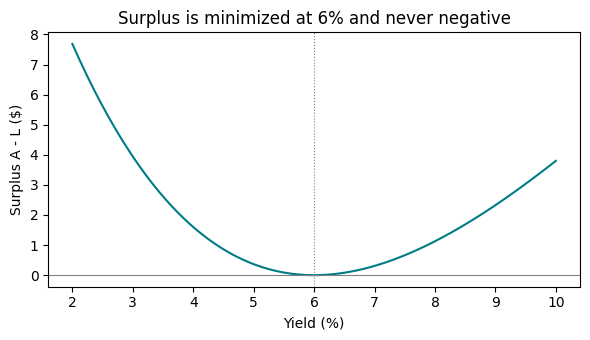

In [11]:
ys = np.linspace(0.02, 0.10, 200)
plt.figure(figsize=(6, 3.5))
plt.plot(ys * 100, [surplus(v) for v in ys], color="#007C85")
plt.axhline(0, color="gray", lw=0.8)
plt.axvline(6, color="gray", lw=0.8, ls=":")
plt.xlabel("Yield (%)")
plt.ylabel("Surplus A - L ($)")
plt.title("Surplus is minimized at 6% and never negative")
plt.tight_layout()
plt.show()

## Your turn

1. Change the bond in Section 2 to a **semiannual** 6% coupon. Use $P(y) = \sum CF_t\,(1 + y/2)^{-2t}$, differentiate, and compare $D^*$ and $C$ with QuantLib's `ql.Semiannual` frequency. Remember that the guide divides $\sum n(n+1)\,PV_n$ by $k^2 = 4$ when time is counted in half-years.
2. In Section 8, move the 5-year zero to year 7 and re-solve for the weight that matches duration 8. Does the convexity condition still hold? What does that say about how widely assets should be spread around the liability date?
3. Add a third derivative check: compute $P'''/P$ by finite differences and compare it with the SymPy value of $-753.69$.